## Set up Graph Overlay

### Basics of Graph

In [1]:
import numpy as np, networkx as nx
# import watts_model as wtm, gudhi_persistence as gp, utilsA1 as utils
import os, json, pandas as pd

## Variables
base_PATH = os.path.realpath(os.path.join(os.getcwd(), "../../"))
base_PATH

'C:\\Users\\sranasin\\PycharmProjects\\NetworkModels'

In [2]:
graph = nx.read_graphml(os.path.join(base_PATH, "resources/masters33.graphml"))
graph = nx.relabel_nodes(graph, int)
schema_info = dict(json.loads(graph.graph['schema_info']))
schema_id = dict(json.loads(graph.graph['schema_id']))

for key, item in schema_id.items():
    print(f" {key}: {item} : {schema_info[key]}")

 d13: FA_std : Standard deviation of FA across streamlines
 d12: fiber_length_mean : Average fiber length (mm)
 d11: fiber_length_std : Std. deviation of fiber length (mm)
 d10: FA_mean : Mean fractional anisotropy along streamlines
 d9: number_of_fibers : Count of streamlines connecting two regions
 d7: dn_hemisphere : Left or right hemisphere
 d6: dn_name : Full region label including hemisphere
 d5: dn_fsname : FreeSurfer base region name
 d4: dn_region : Cortical or subcortical classification
 d3: dn_correspondence_id : Atlas ID used to match regions across subjects
 d2: dn_position_z : DK z-axis centroid position (in mm)
 d1: dn_position_y : DK y-axis centroid position (in mm)
 d0: dn_position_x : DK x-axis centroid position (in mm)


In [3]:
node_df = pd.DataFrame.from_dict(dict(graph.nodes(data = True)), orient = 'index')
node_df.rename(columns = {"dn_correspondence_id":"node_id", "dn_fsname": "dn_old_fsname"}, inplace = True)
# node_df = node_df.astype({'node_id':'int64'})
assert node_df['node_id'].dtype == 'int64', "Relabelling Failed"
assert node_df.index.dtype == 'int64', "Relabelling Failed"
node_df.head(5)

,dn_position_x,dn_position_y,dn_position_z,node_id,dn_region,dn_old_fsname,dn_name,dn_hemisphere
1,34.041923,82.175769,31.776923,1,cortical,lateralorbitofrontal,rh.lateralorbitofrontal,right
2,24.289760,88.730937,36.017429,2,cortical,parsorbitalis,rh.parsorbitalis,right
3,39.947195,100.095710,36.742574,3,cortical,frontalpole,rh.frontalpole,right
4,42.589852,84.868922,32.487844,4,cortical,medialorbitofrontal,rh.medialorbitofrontal,right
5,21.495468,79.767976,39.722054,5,cortical,parstriangularis,rh.parstriangularis,right


In [4]:
def edge_df_from_graph(G):
    graph_edge_df = pd.DataFrame(list(G.edges(data = True)), columns = ['source', 'target', 'attributes'])
    # graph_edge_df = graph_edge_df.astype({'source':'int64', 'target':'int64'})
    assert (graph_edge_df[['source', 'target']].dtypes == ['int64', 'int64']).all(), "Relabelling Failed"

    if graph_edge_df['attributes'].apply(lambda x: isinstance(x, dict)).all():
        attr_df = pd.json_normalize(graph_edge_df['attributes'])
        graph_edge_df = pd.concat([graph_edge_df[['source', 'target']], attr_df], axis = 1)
    return graph_edge_df

edge_df = edge_df_from_graph(graph)
edge_df.head(5)

,source,target,number_of_fibers,FA_mean,fiber_length_std,fiber_length_mean,FA_std
0,1,2,5.629108,0.178234,0.816500,15.957570,0.116143
1,1,36,17.152582,0.373044,13.548146,24.690756,0.159819
2,1,37,85.394366,0.414124,9.933109,26.245858,0.149843
3,1,7,54.953052,0.338660,6.342119,23.686359,0.179367
4,1,8,11.751174,0.511627,7.169767,30.634023,0.156943


#### Import ADNI/other Data

In [9]:
# SUVR or Volume or other Data
df = pd.read_csv(os.path.join(base_PATH, "resources/adni_pet_image_analysis/AMY/structured_files_UCBERKELEY_AMY_6MM_29Oct2025/UCBERKELEY_AMY_6MM_29Oct2025_suvr.csv"))
dftype = "suvr"
df.head(5)

,loniuid,ptid,rid,rh.lateralorbitofrontal,rh.parsorbitalis,rh.frontalpole,rh.medialorbitofrontal,rh.parstriangularis,rh.parsopercularis,rh.rostralmiddlefrontal,...,lh.transversetemporal,lh.insula,Left-Thalamus-Proper,Left-Caudate,Left-Putamen,Left-Pallidum,Left-Accumbens-area,Left-Hippocampus,Left-Amygdala,Brain-Stem
0,1602753,141_S_0767,767,1.207,1.128,0.978,1.029,1.098,1.037,1.008,...,1.077,1.102,1.086,0.943,1.359,1.734,0.832,1.126,0.959,1.630
1,1598063,037_S_4214,4214,1.082,1.010,0.772,0.872,1.036,0.972,0.974,...,0.979,1.008,1.277,1.002,1.261,1.699,0.955,1.016,1.001,1.688
2,1598059,037_S_4214,4214,1.101,1.003,0.733,0.956,1.011,0.983,0.935,...,1.010,1.001,1.178,0.948,1.249,1.532,0.952,0.981,0.999,1.568
3,1614231,037_S_4214,4214,1.097,1.002,0.815,0.911,1.059,1.017,1.005,...,0.987,1.010,1.241,0.987,1.326,1.727,0.991,0.953,1.056,1.672
4,1594117,006_S_4485,4485,1.723,1.737,1.666,1.661,1.757,1.765,1.741,...,0.943,1.218,1.324,1.042,1.359,1.707,1.127,1.141,1.004,1.709


####  Mapping of ADNI/oxMBM to preffered names

In [8]:
dnnames_mapping = pd.read_csv(os.path.join(base_PATH, "resources", "adni_pet_image_analysis", "AMY", "structured_files_UCBERKELEY_AMY_6MM_29Oct2025", "UCBERKELEY_AMY_6MM_29Oct2025_mapping.csv"))

map_dict = dict(zip(dnnames_mapping['dnnames'], dnnames_mapping['fsname']))

In [10]:
info_df = pd.merge(node_df, dnnames_mapping, how = 'left', left_on = 'dn_name', right_on = 'dnnames')
assert info_df.shape[0] == node_df.shape[0], "Not a One to One to merger"

In [11]:
# rename the columns of the data file
df.rename(columns=map_dict, inplace=True)

# rename graph
for node in graph.nodes():
    graph.nodes[node]['region_name'] = map_dict[graph.nodes[node]['dn_name']]
### Create new graph from filtered node properties if needed

In [12]:
graph.nodes[1]

{'dn_position_x': 34.0419230769,
 'dn_position_y': 82.1757692308,
 'dn_position_z': 31.7769230769,
 'dn_correspondence_id': 1,
 'dn_region': 'cortical',
 'dn_fsname': 'lateralorbitofrontal',
 'dn_name': 'rh.lateralorbitofrontal',
 'dn_hemisphere': 'right',
 'region_name': 'rh_lateralorbitofrontal'}

#### Setting {var_type} data into nx.Graph

In [15]:
print(f"Imported DF contains data for: {dftype} data of patients")
selected_patient_RID = 4214
df_id = np.random.choice(df[df['rid'] == selected_patient_RID].index)

Imported DF contains data for: suvr data of patients


In [16]:
for node in graph.nodes():
    graph.nodes[node][dftype] = df.loc[df_id, graph.nodes[node]['region_name']]

#### Export graph as graphml (for Gephi)

In [19]:
import utils_a3 as utils

utils.export_graphml_with_namespace(
    graph,
    output_path=os.path.realpath(os.path.join(base_PATH, "resources/suvr_updated.graphml")),
    xmlns_path="file:///C:/Users/sranasin/PycharmProjects/NetworkModels/resources/graphml.xsd"
)

GraphML exported to: \\BAY.math.ttu.edu\users$\sranasin\Academic\NetworkModels\resources\suvr_updated.graphml


### 3D-Visualization

In [17]:
import plotly.graph_objects as go
import plotly.io as pio

import base64
from PIL import Image
pio.renderers.default = "browser"


In [18]:
# Extract 3D positions from node attributes
pos = {}
for node, data in graph.nodes(data=True):
    x = float(data.get('dn_position_x', 0))
    y = float(data.get('dn_position_y', 0))
    z = float(data.get('dn_position_z', 0))
    pos[node] = (x, y, z)


In [19]:
edge_x, edge_y, edge_z = [], [], []
for u, v, edge_data in graph.edges(data=True):
    x0, y0, z0 = pos[u]
    x1, y1, z1 = pos[v]
    edge_x += [x0, x1, None] # Edge coordinates
    edge_y += [y0, y1, None]
    edge_z += [z0, z1, None]

In [20]:
# NOde coordinates
x_nodes = [pos[n][0] for n in graph.nodes()]
y_nodes = [pos[n][1] for n in graph.nodes()]
z_nodes = [pos[n][2] for n in graph.nodes()]

# Name and color each Node with regions and SUVR
labels = [graph.nodes[n].get('region_name', str(n)) for n in graph.nodes()]
suvr_vals = [graph.nodes[node].get('suvr', 0) for node in graph.nodes()]
min_suvr = min(suvr_vals)
max_suvr = max(suvr_vals)
node_color = [(suvr - min_suvr) / (max_suvr - min_suvr) for suvr in suvr_vals]

In [21]:
# --- 5. Plot edges and nodes in Plotly ---
edge_trace = go.Scatter3d(
    x=edge_x, y=edge_y, z=edge_z,
    mode='lines',
    line=dict(color='lightgray', width=1),
    opacity=0.9,
    hoverinfo='none'
)

node_trace = go.Scatter3d(
    x=x_nodes, y=y_nodes, z=z_nodes,
    mode='markers+text',
    # text=labels,
    textposition="top center",
    marker=dict(
        size=20,
        color=node_color,
        colorscale='reds',
        colorbar=dict(title = "SUVR Uptake", tickvals=[0, 1]),
        line=dict(width=0.5, color='darkblue')
    ),
    hovertemplate=(
        "<b>%{text}</b><br>"
        "X: %{x:.2f}<br>"
        "Y: %{y:.2f}<br>"
        "Z: %{z:.2f}<extra></extra>"
    )
)

In [44]:
fig = go.Figure(data=[edge_trace, node_trace])
# fig.update_layout(
#     # scene=dict(                                 # Removed added new scene to kill the grid and labels
#     #     xaxis=dict(showbackground=False),
#     #     yaxis=dict(showbackground=False),
#     #     zaxis=dict(showbackground=False),
#     # ),
#     scene=dict(
#         xaxis=dict(visible=False),
#         yaxis=dict(visible=False),
#         zaxis=dict(visible=False),
#         bgcolor='rgba(0,0,0,0)'  # transparent background
#     ),
#     margin=dict(l=0, r=0, b=0, t=30),
#     title="3D Brain Connectivity Graph - DK33"
# )
fig.update_layout(
    showlegend=False,
    title=None,
    margin=dict(l=0, r=0, t=0, b=0),
    paper_bgcolor='rgba(0,0,0,0)',  # transparent
    plot_bgcolor='rgba(0,0,0,0)',
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        bgcolor='rgba(0,0,0,0)'
    )
)
# fig.add_layout_image(
#     dict(
#         source=f"data:image/png;base64,{encoded}",
#         xref="paper", yref="paper",
#         x=0.5, y=0.6,
#         sizex=1, sizey=1,
#         xanchor="center", yanchor="middle",
#         opacity=0.3,
#         layer="below"
#     )
# )
fig.show()

In [23]:
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "browser"

# ── Braak stage definitions (cumulative — each stage includes all prior) ──────
# Stage I–II:  transentorhinal (entorhinal, hippocampus, parahippocampal)
# Stage III–IV: limbic (+ amygdala, cingulate, insula, thalamus)
# Stage V–VI:  neocortical (+ association + primary cortices)

BRAAK_CUMULATIVE = {
    2: {
        'lh_entorhinal', 'rh_entorhinal',
        'lh_hippocampus', 'rh_hippocampus',
        'lh_parahippocampal', 'rh_parahippocampal',
    },
    3: {
        # Stage II regions (inherited)
        'lh_entorhinal', 'rh_entorhinal',
        'lh_hippocampus', 'rh_hippocampus',
        'lh_parahippocampal', 'rh_parahippocampal',
        # Stage III–IV additions
        'lh_amygdala', 'rh_amygdala',
        'lh_rostralanteriorcingulate', 'rh_rostralanteriorcingulate',
        'lh_caudalanteriorcingulate', 'rh_caudalanteriorcingulate',
        'lh_posteriorcingulate', 'rh_posteriorcingulate'},


    4: {# Stage II regions (inherited)
        'lh_entorhinal', 'rh_entorhinal',
        'lh_hippocampus', 'rh_hippocampus',
        'lh_parahippocampal', 'rh_parahippocampal',
        # Stage III–IV additions
        'lh_amygdala', 'rh_amygdala',
        'lh_rostralanteriorcingulate', 'rh_rostralanteriorcingulate',
        'lh_caudalanteriorcingulate', 'rh_caudalanteriorcingulate',
        'lh_posteriorcingulate', 'rh_posteriorcingulate',
        ## New stage IV
        'lh_isthmuscingulate', 'rh_isthmuscingulate',
        'lh_insula', 'rh_insula',
        'lh_thalamus_proper', 'rh_thalamus_proper',
        'lh_temporalpole', 'rh_temporalpole',
    },
    6: {
        # Stage II regions (inherited)
        'lh_entorhinal', 'rh_entorhinal',
        'lh_hippocampus', 'rh_hippocampus',
        'lh_parahippocampal', 'rh_parahippocampal',
        # Stage III–IV additions (inherited)
        'lh_amygdala', 'rh_amygdala',
        'lh_rostralanteriorcingulate', 'rh_rostralanteriorcingulate',
        'lh_caudalanteriorcingulate', 'rh_caudalanteriorcingulate',
        'lh_posteriorcingulate', 'rh_posteriorcingulate',
        'lh_isthmuscingulate', 'rh_isthmuscingulate',
        'lh_insula', 'rh_insula',
        'lh_thalamus_proper', 'rh_thalamus_proper',
        'lh_temporalpole', 'rh_temporalpole',
        # Stage V–VI additions (association + primary cortices)
        'lh_inferiortemporal', 'rh_inferiortemporal',
        'lh_middletemporal', 'rh_middletemporal',
        'lh_superiortemporal', 'rh_superiortemporal',
        'lh_bankssts', 'rh_bankssts',
        'lh_transversetemporal', 'rh_transversetemporal',
        'lh_fusiform', 'rh_fusiform',
        'lh_lingual', 'rh_lingual',
        'lh_lateraloccipital', 'rh_lateraloccipital',
        'lh_pericalcarine', 'rh_pericalcarine',
        'lh_cuneus', 'rh_cuneus',
        'lh_precuneus', 'rh_precuneus',
        'lh_inferiorparietal', 'rh_inferiorparietal',
        'lh_superiorparietal', 'rh_superiorparietal',
        'lh_supramarginal', 'rh_supramarginal',
        'lh_postcentral', 'rh_postcentral',
        'lh_precentral', 'rh_precentral',
        'lh_paracentral', 'rh_paracentral',
        'lh_rostralmiddlefrontal', 'rh_rostralmiddlefrontal',
        'lh_caudalmiddlefrontal', 'rh_caudalmiddlefrontal',
        'lh_superiorfrontal', 'rh_superiorfrontal',
        'lh_lateralorbitofrontal', 'rh_lateralorbitofrontal',
        'lh_medialorbitofrontal', 'rh_medialorbitofrontal',
        'lh_parsorbitalis', 'rh_parsorbitalis',
        'lh_frontalpole', 'rh_frontalpole',
        'lh_parstriangularis', 'rh_parstriangularis',
        'lh_parsopercularis', 'rh_parsopercularis',
        'lh_caudate', 'rh_caudate',
        'lh_putamen', 'rh_putamen',
        'lh_pallidum', 'rh_pallidum',
        'lh_accumbens_area', 'rh_accumbens_area',
        'brainstem',
    },
}

# ── Set your desired stage here ───────────────────────────────────────────────
stage = 2  # change to 4 or 6

activated_regions = BRAAK_CUMULATIVE[stage]

# ── Node colors: activated = red, inactive = light gray ──────────────────────
ACTIVE_COLOR   = '#1C3A3A'
INACTIVE_COLOR = '#D3D1C7'
ACTIVE_SIZE    = 35
INACTIVE_SIZE  = 0

# ── Extract positions ─────────────────────────────────────────────────────────
pos = {}
for node, data in graph.nodes(data=True):
    pos[node] = (
        float(data.get('dn_position_x', 0)),
        float(data.get('dn_position_y', 0)),
        float(data.get('dn_position_z', 0)),
    )

# ── Edges — split into active (both endpoints activated) vs inactive ──────────
act_ex, act_ey, act_ez = [], [], []   # both endpoints active
ina_ex, ina_ey, ina_ez = [], [], []   # at least one endpoint inactive

for u, v, data in graph.edges(data=True):
    x0, y0, z0 = pos[u]
    x1, y1, z1 = pos[v]
    u_region = graph.nodes[u].get('region_name', str(u))
    v_region = graph.nodes[v].get('region_name', str(v))

    if u_region in activated_regions and v_region in activated_regions:
        act_ex += [x0, x1, None]
        act_ey += [y0, y1, None]
        act_ez += [z0, z1, None]
    else:
        ina_ex += [x0, x1, None]
        ina_ey += [y0, y1, None]
        ina_ez += [z0, z1, None]

# ── Nodes ─────────────────────────────────────────────────────────────────────
x_nodes, y_nodes, z_nodes = [], [], []
node_colors, node_sizes, node_labels = [], [], []

for n, data in graph.nodes(data=True):
    x_nodes.append(pos[n][0])
    y_nodes.append(pos[n][1])
    z_nodes.append(pos[n][2])

    region = data.get('region_name', str(n))
    node_labels.append(region)

    is_active = region in activated_regions
    node_colors.append(ACTIVE_COLOR if is_active else INACTIVE_COLOR)
    node_sizes.append(ACTIVE_SIZE if is_active else INACTIVE_SIZE)

# ── Traces ────────────────────────────────────────────────────────────────────
inactive_edge_trace = go.Scatter3d(
    x=ina_ex, y=ina_ey, z=ina_ez,
    mode='lines',
    line=dict(color='rgba(0,0,0,0)', width=1),  # fully transparent
    hoverinfo='none',
    showlegend=False
)

active_edge_trace = go.Scatter3d(
    x=act_ex, y=act_ey, z=act_ez,
    mode='lines',
    line=dict(color=ACTIVE_COLOR, width=3),
    opacity=0.6,
    hoverinfo='none',
    showlegend=False
)

node_trace = go.Scatter3d(
    x=x_nodes, y=y_nodes, z=z_nodes,
    mode='markers',
    text=node_labels,
    marker=dict(
        size=node_sizes,
        color=node_colors,
        line=dict(width=0.5, color='darkblue')
    ),
    hovertemplate=(
        "<b>%{text}</b><br>"
        "X: %{x:.2f}<br>"
        "Y: %{y:.2f}<br>"
        "Z: %{z:.2f}<extra></extra>"
    )
)

# ── Layout ────────────────────────────────────────────────────────────────────
stage_labels = {2: 'I–II', 4: 'III–IV', 6: 'V–VI'}

fig = go.Figure(data=[inactive_edge_trace, active_edge_trace, node_trace])
fig.update_layout(
    title=f"Braak Stage {stage_labels[stage]} — DK33 Connectome",
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        bgcolor='rgba(0,0,0,0)',
    ),
    paper_bgcolor='rgba(0,0,0,0)',
    margin=dict(l=0, r=0, b=0, t=40),
)

# fig.show()

In [51]:
braak_activation = [
    3,  # 0  rh_lateralorbitofrontal
    3,  # 1  rh_parsorbitalis
    3,  # 0  rh_frontalpole
    3,  # 1  rh_medialorbitofrontal
    3,  # 2  rh_parstriangularis
    3,  # 5  rh_parsopercularis
    3,  # 3  rh_rostralmiddlefrontal
    3,  # 7  rh_superiorfrontal
    3,  # 8  rh_caudalmiddlefrontal
    3,  # 9  rh_precentral
    3,  # 10 rh_paracentral
    1,  # 11 rh_rostralanteriorcingulate
    1,  # 10 rh_caudalanteriorcingulate
    1,  # 11 rh_posteriorcingulate
    2,  # 12 rh_isthmuscingulate
    3,  # 15 rh_postcentral
    3,  # 13 rh_supramarginal
    3,  # 17 rh_superiorparietal
    3,  # 18 rh_inferiorparietal
    3,  # 19 rh_precuneus
    3,  # 00 rh_cuneus
    3,  # 01 rh_pericalcarine
    3,  # 00 rh_lateraloccipital
    3,  # 01 rh_lingual
    3,  # 02 rh_fusiform
    0,  # 05 rh_parahippocampal
    0,  # 03 rh_entorhinal
    2,  # 07 rh_temporalpole
    3,  # 08 rh_inferiortemporal
    3,  # 09 rh_middletemporal
    3,  # 10 rh_bankssts
    3,  # 11 rh_superiortemporal
    3,  # 10 rh_transversetemporal
    2,  # 11 rh_insula
    2,  # 12 rh_thalamus_proper
    3,  # 15 rh_caudate
    3,  # 13 rh_putamen
    3,  # 17 rh_pallidum
    3,  # 18 rh_accumbens_area
    0,  # 19 rh_hippocampus
    1,  # 20 rh_amygdala
    3,  # 21 lh_lateralorbitofrontal
    3,  # 20 lh_parsorbitalis
    3,  # 21 lh_frontalpole
    3,  # 22 lh_medialorbitofrontal
    3,  # 25 lh_parstriangularis
    3,  # 23 lh_parsopercularis
    3,  # 27 lh_rostralmiddlefrontal
    3,  # 28 lh_superiorfrontal
    3,  # 29 lh_caudalmiddlefrontal
    3,  # 50 lh_precentral
    3,  # 51 lh_paracentral
    1,  # 50 lh_rostralanteriorcingulate
    1,  # 51 lh_caudalanteriorcingulate
    1,  # 52 lh_posteriorcingulate
    2,  # 55 lh_isthmuscingulate
    3,  # 53 lh_postcentral
    3,  # 57 lh_supramarginal
    3,  # 58 lh_superiorparietal
    3,  # 59 lh_inferiorparietal
    3,  # 30 lh_precuneus
    3,  # 31 lh_cuneus
    3,  # 30 lh_pericalcarine
    3,  # 31 lh_lateraloccipital
    3,  # 32 lh_lingual
    3,  # 35 lh_fusiform
    0,  # 33 lh_parahippocampal
    0,  # 37 lh_entorhinal
    2,  # 38 lh_temporalpole
    3,  # 39 lh_inferiortemporal
    3,  # 70 lh_middletemporal
    3,  # 71 lh_bankssts
    3,  # 70 lh_superiortemporal
    3,  # 71 lh_transversetemporal
    2,  # 72 lh_insula
    2,  # 75 lh_thalamus_proper
    3,  # 73 lh_caudate
    3,  # 77 lh_putamen
    3,  # 78 lh_pallidum
    3,  # 79 lh_accumbens_area
    0,  # 80 lh_hippocampus
    1,  # 81 lh_amygdala
    3,  # 80 brainstem
]

In [53]:
import gudhi_persistence_a3 as gd
import gudhi

nx.set_edge_attributes(graph, 0, "weight1")
betti, persistence_gd, persistence_for_graphics_gd = gd.compute_persistence(graph, braak_activation, ngeom_edges_in_persistence=True)

In [56]:
persistence_gd

array([[list([(0.0, inf)]), list([]), list([])],
       [list([(0.0, inf)]),
        list([(1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf)]),
        list([])],
       [list([(0.0, inf)]),
        list([(1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (2.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (1.0, inf), (2.0, inf), (2.0, inf), (2.0, inf), (2.0, inf), (2.0, inf), (2.0, inf), (2.0, inf), (2.0, inf), (2.0, inf), (2.0, inf), (2.0, inf), (2.0, 

<Axes: title={'center': 'Persistence diagram'}, xlabel='Birth', ylabel='Death'>

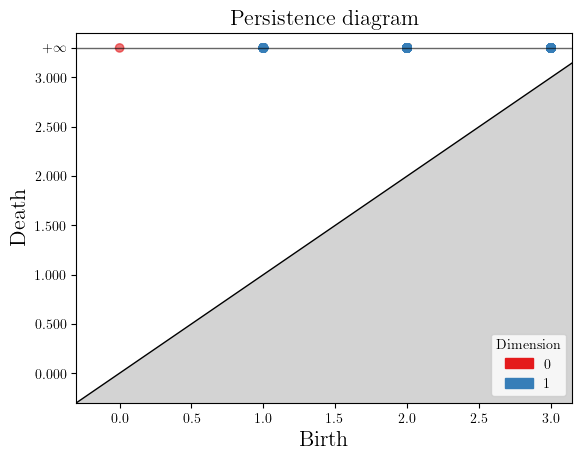

In [55]:
gudhi.persistence_graphical_tools.plot_persistence_diagram(
        persistence_for_graphics_gd, legend=True
    )

In [48]:
import gudhi
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from itertools import combinations

# ── Braak stage definitions (same as connectome script) ───────────────────────
BRAAK_CUMULATIVE = {
    2: {
        'lh_entorhinal', 'rh_entorhinal',
        'lh_hippocampus', 'rh_hippocampus',
        'lh_parahippocampal', 'rh_parahippocampal',
    },
    3: {
        # Stage II regions (inherited)
        'lh_entorhinal', 'rh_entorhinal',
        'lh_hippocampus', 'rh_hippocampus',
        'lh_parahippocampal', 'rh_parahippocampal',
        # Stage III additions
        'lh_amygdala', 'rh_amygdala',
        'lh_rostralanteriorcingulate', 'rh_rostralanteriorcingulate',
        'lh_caudalanteriorcingulate', 'rh_caudalanteriorcingulate',
        'lh_posteriorcingulate', 'rh_posteriorcingulate'},


    4: {# Stage II regions (inherited)
        'lh_entorhinal', 'rh_entorhinal',
        'lh_hippocampus', 'rh_hippocampus',
        'lh_parahippocampal', 'rh_parahippocampal',
        # Stage III regions (inherited)
        'lh_amygdala', 'rh_amygdala',
        'lh_rostralanteriorcingulate', 'rh_rostralanteriorcingulate',
        'lh_caudalanteriorcingulate', 'rh_caudalanteriorcingulate',
        'lh_posteriorcingulate', 'rh_posteriorcingulate',
        ## Stage IV additions
        'lh_isthmuscingulate', 'rh_isthmuscingulate',
        'lh_insula', 'rh_insula',
        'lh_thalamus_proper', 'rh_thalamus_proper',
        'lh_temporalpole', 'rh_temporalpole'},


    6: {
        # Stage II regions (inherited)
        'lh_entorhinal', 'rh_entorhinal',
        'lh_hippocampus', 'rh_hippocampus',
        'lh_parahippocampal', 'rh_parahippocampal',
        # Stage III–IV additions (inherited)
        'lh_amygdala', 'rh_amygdala',
        'lh_rostralanteriorcingulate', 'rh_rostralanteriorcingulate',
        'lh_caudalanteriorcingulate', 'rh_caudalanteriorcingulate',
        'lh_posteriorcingulate', 'rh_posteriorcingulate',
        'lh_isthmuscingulate', 'rh_isthmuscingulate',
        'lh_insula', 'rh_insula',
        'lh_thalamus_proper', 'rh_thalamus_proper',
        'lh_temporalpole', 'rh_temporalpole',
        # Stage V–VI additions (association + primary cortices)
        'lh_inferiortemporal', 'rh_inferiortemporal',
        'lh_middletemporal', 'rh_middletemporal',
        'lh_superiortemporal', 'rh_superiortemporal',
        'lh_bankssts', 'rh_bankssts',
        'lh_transversetemporal', 'rh_transversetemporal',
        'lh_fusiform', 'rh_fusiform',
        'lh_lingual', 'rh_lingual',
        'lh_lateraloccipital', 'rh_lateraloccipital',
        'lh_pericalcarine', 'rh_pericalcarine',
        'lh_cuneus', 'rh_cuneus',
        'lh_precuneus', 'rh_precuneus',
        'lh_inferiorparietal', 'rh_inferiorparietal',
        'lh_superiorparietal', 'rh_superiorparietal',
        'lh_supramarginal', 'rh_supramarginal',
        'lh_postcentral', 'rh_postcentral',
        'lh_precentral', 'rh_precentral',
        'lh_paracentral', 'rh_paracentral',
        'lh_rostralmiddlefrontal', 'rh_rostralmiddlefrontal',
        'lh_caudalmiddlefrontal', 'rh_caudalmiddlefrontal',
        'lh_superiorfrontal', 'rh_superiorfrontal',
        'lh_lateralorbitofrontal', 'rh_lateralorbitofrontal',
        'lh_medialorbitofrontal', 'rh_medialorbitofrontal',
        'lh_parsorbitalis', 'rh_parsorbitalis',
        'lh_frontalpole', 'rh_frontalpole',
        'lh_parstriangularis', 'rh_parstriangularis',
        'lh_parsopercularis', 'rh_parsopercularis',
        'lh_caudate', 'rh_caudate',
        'lh_putamen', 'rh_putamen',
        'lh_pallidum', 'rh_pallidum',
        'lh_accumbens_area', 'rh_accumbens_area',
        'brainstem',
    },
}

STAGE_LABELS = {2: 'I–II', 3: 'III', 4: 'III-IV', 6: 'V–VI'}
STAGE_COLORS = {2: '#4C9BE8', 3: '#FF0000', 4: '#E8A23C', 6: '#E8593C'}

# ── Build node index map (gudhi needs integer simplices) ──────────────────────
nodes     = list(graph.nodes())
node2idx  = {n: i for i, n in enumerate(nodes)}

# ── Build simplex tree for a given stage ─────────────────────────────────────
def build_simplex_tree(st, stage, filt, compute_persistence="yes"):
    activated = BRAAK_CUMULATIVE[stage]

    if compute_persistence=="yes":
        st = gudhi.SimplexTree()

    for n, data in graph.nodes(data=True):
        region = data.get('region_name', str(n))
        st.insert([node2idx[n]], filtration=filt)

    for u, v, data in graph.edges(data=True):
        u_region = graph.nodes[u].get('region_name', str(u))
        v_region = graph.nodes[v].get('region_name', str(v))
        # Edge enters at max of its two endpoint filtrations
        # (inf if either endpoint is inactive → edge excluded)
        u_filt = 0.0 if u_region in activated else float('inf')
        v_filt = 0.0 if v_region in activated else float('inf')
        st.insert([node2idx[u], node2idx[v]], filtration=max(u_filt, v_filt))

    if compute_persistence=="yes":
        st.compute_persistence()
    return st


# ── Compute all three stages ──────────────────────────────────────────────────
# simplex_trees = {s: build_simplex_tree(s) for s,t  in enumerate([0, 1, 2, 3], [2, 3, 4, 6])}
st = gudhi.SimplexTree()

for filtration, stage in enumerate([2, 3, 4, 6]):
    print(f"Stage {stage} with Filtration: {filtration}")
    st = build_simplex_tree(st=None, stage=stage, filt=filtration, compute_persistence="yes")

Stage 2 with Filtration: 0
Stage 3 with Filtration: 1
Stage 4 with Filtration: 2
Stage 6 with Filtration: 3


In [49]:
for node, data in graph.nodes(data = True):
    print(f"Node {node} region name: {data['region_name']}")

Node 1 region name: rh_lateralorbitofrontal
Node 2 region name: rh_parsorbitalis
Node 3 region name: rh_frontalpole
Node 4 region name: rh_medialorbitofrontal
Node 5 region name: rh_parstriangularis
Node 6 region name: rh_parsopercularis
Node 7 region name: rh_rostralmiddlefrontal
Node 8 region name: rh_superiorfrontal
Node 9 region name: rh_caudalmiddlefrontal
Node 10 region name: rh_precentral
Node 11 region name: rh_paracentral
Node 12 region name: rh_rostralanteriorcingulate
Node 13 region name: rh_caudalanteriorcingulate
Node 14 region name: rh_posteriorcingulate
Node 15 region name: rh_isthmuscingulate
Node 16 region name: rh_postcentral
Node 17 region name: rh_supramarginal
Node 18 region name: rh_superiorparietal
Node 19 region name: rh_inferiorparietal
Node 20 region name: rh_precuneus
Node 21 region name: rh_cuneus
Node 22 region name: rh_pericalcarine
Node 23 region name: rh_lateraloccipital
Node 24 region name: rh_lingual
Node 25 region name: rh_fusiform
Node 26 region name

In [ ]:


# Extract persistence pairs per stage (filter out inf death values for plotting)
def get_pairs(st, dim):
    return [
        (b, d) for (p_dim, (b, d))
        in st.persistence()
        if p_dim == dim and d != float('inf')
    ]

# ── Bottleneck distances between stages ──────────────────────────────────────
def bottleneck(st_a, st_b, dim):
    dgm_a = st_a.persistence_intervals_in_dimension(dim)
    dgm_b = st_b.persistence_intervals_in_dimension(dim)
    # Remove infinite bars before comparison
    dgm_a = dgm_a[dgm_a[:, 1] != np.inf] if len(dgm_a) else dgm_a
    dgm_b = dgm_b[dgm_b[:, 1] != np.inf] if len(dgm_b) else dgm_b
    return gudhi.bottleneck_distance(dgm_a, dgm_b)

stage_pairs = [(2, 4), (4, 6), (2, 6)]
bn_distances = {}
for dim in [0, 1]:
    bn_distances[dim] = {}
    for s1, s2 in stage_pairs:
        d = bottleneck(simplex_trees[s1], simplex_trees[s2], dim)
        bn_distances[dim][(s1, s2)] = d

# ── Plotting ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14), facecolor='#1a1a1a')
fig.suptitle('Braak Stage Topology — Persistence Analysis',
             color='white', fontsize=15, fontweight='bold', y=0.98)

# Grid: row 0 = persistence diagrams (H0, H1) × 3 stages
#        row 1 = barcodes × 3 stages
#        row 2 = bottleneck heatmaps (H0, H1)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Row 0: Persistence diagrams ───────────────────────────────────────────────
for col, stage in enumerate([2, 4, 6]):
    ax = fig.add_subplot(gs[0, col])
    ax.set_facecolor('#111111')
    color = STAGE_COLORS[stage]

    for dim, marker, label in [(0, 'o', 'H₀'), (1, '^', 'H₁')]:
        pairs = get_pairs(simplex_trees[stage], dim)
        if pairs:
            b, d = zip(*pairs)
            ax.scatter(b, d, c=color, marker=marker, s=40,
                       alpha=0.8, label=label, edgecolors='white', linewidths=0.3)

    # Diagonal
    lim = 1.1
    ax.plot([0, lim], [0, lim], color='gray', lw=0.8, linestyle='--', alpha=0.5)
    ax.set_xlim(-0.05, lim)
    ax.set_ylim(-0.05, lim)
    ax.set_xlabel('Birth', color='#aaaaaa', fontsize=9)
    ax.set_ylabel('Death', color='#aaaaaa', fontsize=9)
    ax.set_title(f'Stage {STAGE_LABELS[stage]}', color=color, fontsize=11, fontweight='bold')
    ax.tick_params(colors='#aaaaaa', labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')
    ax.legend(fontsize=8, facecolor='#222222', labelcolor='white',
              edgecolor='#444444', loc='lower right')

# ── Row 1: Barcodes ───────────────────────────────────────────────────────────
for col, stage in enumerate([2, 4, 6]):
    ax = fig.add_subplot(gs[1, col])
    ax.set_facecolor('#111111')
    color = STAGE_COLORS[stage]

    y = 0
    bar_h = 0.6
    yticks, ylabels = [], []

    for dim, dim_color, dim_label in [
        (0, color,        'H₀'),
        (1, '#ffffff',    'H₁'),
    ]:
        pairs = get_pairs(simplex_trees[stage], dim)
        # Sort by persistence (death - birth) descending so longest bars are on top
        pairs = sorted(pairs, key=lambda x: x[1] - x[0], reverse=True)
        for b, d in pairs:
            ax.barh(y, d - b, left=b, height=bar_h,
                    color=dim_color, alpha=0.75, edgecolor='none')
            y += 1
        if pairs:
            yticks.append(y - len(pairs) // 2)
            ylabels.append(dim_label)
        y += 1  # gap between dimensions

    ax.set_xlabel('Filtration value', color='#aaaaaa', fontsize=9)
    ax.set_title(f'Stage {STAGE_LABELS[stage]}', color=color, fontsize=11, fontweight='bold')
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, color='#aaaaaa', fontsize=9)
    ax.tick_params(axis='x', colors='#aaaaaa', labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')

# ── Row 2: Bottleneck distance heatmaps ───────────────────────────────────────
labels_order = [2, 4, 6]
tick_labels  = [STAGE_LABELS[s] for s in labels_order]

for col, (dim, dim_label) in enumerate([(0, 'H₀'), (1, 'H₁')]):
    ax = fig.add_subplot(gs[2, col])
    ax.set_facecolor('#111111')

    # Build 3×3 symmetric matrix
    mat = np.zeros((3, 3))
    for i, s1 in enumerate(labels_order):
        for j, s2 in enumerate(labels_order):
            if i == j:
                mat[i, j] = 0
            else:
                key = (min(s1, s2), max(s1, s2))
                mat[i, j] = bn_distances[dim].get(key, 0)

    im = ax.imshow(mat, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(tick_labels, color='#aaaaaa', fontsize=9)
    ax.set_yticklabels(tick_labels, color='#aaaaaa', fontsize=9)
    ax.set_title(f'Bottleneck Distance — {dim_label}',
                 color='white', fontsize=11, fontweight='bold')

    # Annotate cells
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{mat[i,j]:.3f}',
                    ha='center', va='center',
                    color='black' if mat[i,j] > mat.max()*0.5 else 'white',
                    fontsize=9, fontweight='bold')

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(colors='#aaaaaa')

# Leave gs[2,2] empty or add a legend/notes
ax_note = fig.add_subplot(gs[2, 2])
ax_note.set_facecolor('#111111')
ax_note.axis('off')
note = (
    "Notes\n\n"
    "H₀  Connected components\n"
    "H₁  Independent loops\n\n"
    "Bottleneck distance measures\n"
    "the largest shift needed to\n"
    "match two persistence diagrams.\n\n"
    "Larger = more topological\n"
    "change between stages."
)
ax_note.text(0.05, 0.95, note, transform=ax_note.transAxes,
             color='#aaaaaa', fontsize=9, va='top', linespacing=1.7,
             fontfamily='monospace')

plt.savefig('braak_persistence.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1a1a')
plt.show()

### Node activations

In [2]:
import utils_a3 as utils
import os, pandas as pd, numpy as np

In [4]:
df = pd.read_csv(os.path.realpath(os.path.join(utils.BASE_DIR, "resources/TEST_NEW/structured_files_UCBERKELEY_AMY_6MM_29Oct2025/UCBERKELEY_AMY_6MM_29Oct2025_suvr.csv")))
dftype = "suvr"

In [5]:
dnnames_mapping = pd.read_csv(os.path.realpath(os.path.join(utils.BASE_DIR, "resources/TEST_NEW/structured_files_UCBERKELEY_AMY_6MM_29Oct2025/UCBERKELEY_AMY_6MM_29Oct2025_mapping.csv")))

map_dict = dict(zip(dnnames_mapping['dnnames'], dnnames_mapping['fsname']))
df.rename(columns=map_dict, inplace=True)

{'dn_position_x': 34.0419230769,
 'dn_position_y': 82.1757692308,
 'dn_position_z': 31.7769230769,
 'dn_correspondence_id': 1,
 'dn_region': 'cortical',
 'dn_fsname': 'lateralorbitofrontal',
 'dn_name': 'rh.lateralorbitofrontal',
 'dn_hemisphere': 'right',
 'region_name': 'rh_lateralorbitofrontal'}

In [6]:
df.head(10)

,dn_position_x,dn_position_y,dn_position_z,dn_correspondence_id,dn_region,dn_fsname,dn_name,dn_hemisphere,region_name
1,34.041923,82.175769,31.776923,1,cortical,lateralorbitofrontal,rh.lateralorbitofrontal,right,rh_lateralorbitofrontal
2,24.289760,88.730937,36.017429,2,cortical,parsorbitalis,rh.parsorbitalis,right,rh_parsorbitalis
3,39.947195,100.095710,36.742574,3,cortical,frontalpole,rh.frontalpole,right,rh_frontalpole
4,42.589852,84.868922,32.487844,4,cortical,medialorbitofrontal,rh.medialorbitofrontal,right,rh_medialorbitofrontal
5,21.495468,79.767976,39.722054,5,cortical,parstriangularis,rh.parstriangularis,right,rh_parstriangularis
...,...,...,...,...,...,...,...,...,...
79,54.325472,61.332547,34.375000,79,subcortical,Left-Pallidum,Left-Pallidum,left,lh_pallidum
80,48.334152,67.886978,32.078624,80,subcortical,Left-Accumbens-area,Left-Accumbens-area,left,lh_accumbens_area
81,58.221491,51.929825,27.666667,81,subcortical,Left-Hippocampus,Left-Hippocampus,left,lh_hippocampus
82,55.997203,63.570629,26.650350,82,subcortical,Left-Amygdala,Left-Amygdala,left,lh_amygdala


In [7]:
df_test = df[(df['qc_flag'].isin((1, 2))) & (df['tracer'].isin(('FBP', 'FBB')))].copy()
df_test.iloc[:, 1:10]

,source,target,number_of_fibers,FA_mean,fiber_length_std,fiber_length_mean,FA_std
0,1,2,5.629108,0.178234,0.816500,15.957570,0.116143
1,1,3,0.328638,0.232833,0.000000,17.045632,0.134898
2,1,4,18.964789,0.310303,3.522724,15.905547,0.152980
3,1,5,34.631455,0.311894,6.899347,20.039535,0.168881
4,1,6,2.532864,0.437655,6.866012,42.794961,0.094890


In [8]:
df_test['tracer_threshold'] = df['tracer'].apply(lambda x: 1.11 if x == "FBP" else 1.08)
df_test.loc[:, ('tracer', 'tracer_threshold')]

In [12]:
for col_name in map_dict.values():
    df_test[f'{col_name}_positivity'] = df_test.apply(lambda row: 1 if row[col_name] > row['tracer_threshold'] else 0, axis = 1)

[(1, 2, 'non_geometric'),
 (1, 3, 'non_geometric'),
 (1, 4, 'non_geometric'),
 (1, 5, 'non_geometric'),
 (1, 6, 'non_geometric'),
 (1, 7, 'non_geometric'),
 (1, 8, 'non_geometric'),
 (1, 9, 'geometric'),
 (1, 10, 'geometric'),
 (1, 11, 'geometric')]

In [14]:
df_test_new_columns = [col  for col in df_test.columns if col.endswith("positivity")]
df_test_new_columns

[(1,
  2,
  {'number_of_fibers': 5.62910798122,
   'FA_mean': 0.178233936269,
   'fiber_length_std': 0.816500084943,
   'fiber_length_mean': 15.9575699282,
   'FA_std': 0.116142955546,
   'type': 'non_geometric'})]

In [ ]:
important_cols = ['rid', 'scandate', 'qc_flag', 'amyloid_status', 'amyloid_status_composite_ref', 'centiloids', 'summary_suvr']
df_test.loc[:, important_cols + df_test_new_columns]

In [ ]:
assert [col.removesuffix("_positivity") for col in df_test.columns if col.endswith("positivity")] == list(utils.NODE_FSREGION_TO_ID.keys())

# activation_times = np.array( of 1's and 0's)
# snapshot = [{set of active at t = 1}, {st of active at t = 1}] # Let's assume that amyloid levels can't regress

In [ ]:
df_test[df_test['amyloid_status'] == 1]

In [ ]:
df_active = df_test.loc[:, ['rid', 'scandate'] + df_test_new_columns]

In [ ]:
df_active.sort_values(by = ['rid', 'scandate'], inplace = True)

In [ ]:

# Example setup
df_active_new = df_test.loc[:, ['rid', 'scandate'] + df_test_new_columns]
df_active_new.sort_values(by = ['rid', 'scandate'], inplace = True)
df_active = df_active_new.head(4)
grouped = df_active.groupby(['rid'], as_index=True)

result = dict()  # store results per group
result_2 = dict()

feature_cols = df_test_new_columns
for group_key, group_df in grouped:
    # drop 'rid' and 'scandate' if they are in columns (they will be index now)
    matrix = group_df[feature_cols].values  # shape [n_rows, n_features], only the 0/1 columns
    n_rows, n_cols = matrix.shape
    cumulative_set = set()
    group_sets = []
    active_t = np.full(n_cols, -1)

    for i in range(n_rows):
        # get indices of 1s in current row
        row_indices = set(np.where(matrix[i])[0])

        # for newly_activated nodes
        newly_activated = row_indices - cumulative_set
        active_t[list(newly_activated)]  = i

        # cumulative union
        cumulative_set = cumulative_set.union(row_indices)
        group_sets.append(cumulative_set.copy())  # copy so each row has its own set

    result[group_key[0]] = group_sets
    result_2[group_key[0]] = active_t


In [ ]:
i = 0
for key, sets in result.items():
    i += 1
    print(f"RID, scandate: {key}")
    for i, s in enumerate(sets):
        print(f"Row {i}: {s}")
    if i > 10:
        break

In [ ]:
result_2[21]

In [ ]:
a = {10, 11, 15}
b = {11, 12}

a.difference(b)

In [ ]:
dir(utils)

In [ ]:
utils.BASE_DIR

In [ ]:
dnnames_dir = utils.MODULE_DIR
os.path.join(utils.MODULE_DIR)

In [60]:
import utils_a3 as utils
import importlib


In [75]:
importlib.reload(utils)
df_path = "resources/TEST_NEW/structured_files_UCBERKELEY_AMY_6MM_29Oct2025/UCBERKELEY_AMY_6MM_29Oct2025_suvr.csv"
df = utils.df_rename_to_fsnames(df_path)
df = utils.safe_filter_df(df, True)
df.sort_values(by = ['rid', 'scandate'], inplace = True)
df = df.head(4)
df, feature_cols = utils.activations_cortical_regions_df(df, True)
activation_times, snapshots, state_values = utils.activation_times_of_patients_for_cortical_regions_df(df, feature_cols, True)


In [25]:
df

,loniuid,ptid,rid,scandate,qc_flag,tracer,amyloid_status,amyloid_status_composite_ref,centiloids,summary_suvr,...,lh_transversetemporal_positivity,lh_insula_positivity,lh_thalamus_proper_positivity,lh_caudate_positivity,lh_putamen_positivity,lh_pallidum_positivity,lh_accumbens_area_positivity,lh_hippocampus_positivity,lh_amygdala_positivity,brainstem_positivity
615,1594517,011_S_0021,21,2010-10-08,2,FBP,0.0,0.0,0.0,1.007,...,0,0,1,1,1,1,0,0,0,1
616,1594530,011_S_0021,21,2012-10-03,2,FBP,0.0,0.0,-9.0,0.956,...,0,0,1,0,1,1,0,0,0,1
617,1594602,011_S_0021,21,2015-11-05,2,FBP,0.0,0.0,-11.0,0.948,...,0,0,1,0,1,1,0,0,0,1
618,1594546,011_S_0021,21,2017-11-28,2,FBP,0.0,0.0,2.0,1.016,...,1,0,1,1,1,1,0,0,0,1


In [67]:
activation_times[767]

array([ 0, -1, -1, -1, -1, -1, -1, -1, -1,  3, -1, -1,  3,  3, -1, -1, -1,
       -1, -1, -1, -1,  0, -1, -1, -1, -1, -1, -1, -1, -1,  0, -1, -1, -1,
        0, -1,  0,  0, -1, -1, -1, -1, -1, -1, -1,  0, -1, -1, -1, -1, -1,
        3, -1,  0,  3,  3, -1, -1, -1, -1, -1, -1,  0, -1, -1, -1, -1, -1,
       -1, -1, -1,  2, -1,  3, -1,  0,  0,  0,  0, -1, -1, -1,  0])

In [5]:
snapshots[4214]

[{0, 10, 13, 30, 34, 36, 37, 42, 51, 71, 75, 77, 78, 82},
 {0,
  10,
  13,
  14,
  19,
  30,
  34,
  36,
  37,
  41,
  42,
  51,
  54,
  55,
  60,
  62,
  63,
  64,
  71,
  75,
  77,
  78,
  82},
 {0,
  10,
  13,
  14,
  19,
  22,
  30,
  34,
  36,
  37,
  41,
  42,
  51,
  54,
  55,
  60,
  62,
  63,
  64,
  65,
  71,
  75,
  77,
  78,
  82}]

#### Fiddle with weights

In [1]:
import utils_a3 as utils
import desikan_killiany_atlas as dkatlas
import importlib
import os, numpy as np, pandas as pd

In [2]:
importlib.reload(utils)
importlib.reload(dkatlas)

# Patient data for graph
DK = dkatlas.DKAtlasGraph()
df = utils.df_rename_to_fsnames(os.path.join("resources/TEST_NEW/structured_files_UCBERKELEY_AMY_6MM_29Oct2025/UCBERKELEY_AMY_6MM_29Oct2025_suvr.csv"))
df = utils.safe_filter_df(df, True)
df.sort_values(by = ['rid', 'scandate'], inplace = True)
# df = df.head(4)


DK.input_patient_data(df.iloc[0, :], df_type = "suvr")
df

,loniuid,ptid,rid,scandate,qc_flag,tracer,amyloid_status,amyloid_status_composite_ref,centiloids,summary_suvr,...,lh_transversetemporal,lh_insula,lh_thalamus_proper,lh_caudate,lh_putamen,lh_pallidum,lh_accumbens_area,lh_hippocampus,lh_amygdala,brainstem
615,1594517,011_S_0021,21,2010-10-08,2,FBP,0.0,0.0,0.0,1.007,...,1.054,1.031,1.159,1.132,1.197,1.392,1.010,1.016,0.924,1.397
616,1594530,011_S_0021,21,2012-10-03,2,FBP,0.0,0.0,-9.0,0.956,...,1.003,0.964,1.249,1.073,1.157,1.376,0.930,1.039,0.947,1.575
617,1594602,011_S_0021,21,2015-11-05,2,FBP,0.0,0.0,-11.0,0.948,...,1.013,0.956,1.175,1.018,1.155,1.470,0.862,1.019,0.864,1.493
618,1594546,011_S_0021,21,2017-11-28,2,FBP,0.0,0.0,2.0,1.016,...,1.122,1.038,1.275,1.298,1.234,1.478,0.965,1.106,0.954,1.571
619,1594569,011_S_0023,23,2010-12-21,2,FBP,1.0,0.0,21.0,1.115,...,1.193,1.059,1.347,1.240,1.343,1.686,1.114,1.286,1.180,1.625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4355,11221070,135_S_10561,10561,2025-03-26,2,FBB,0.0,1.0,17.0,1.075,...,1.115,1.047,1.172,1.066,1.187,1.486,1.041,1.028,0.937,1.509
4502,11242408,036_S_10642,10642,2025-04-22,2,FBP,0.0,0.0,6.0,1.035,...,1.080,0.996,1.082,1.039,1.296,1.752,0.934,1.034,0.970,1.526
4504,11290275,036_S_10649,10649,2025-04-29,2,FBP,0.0,0.0,10.0,1.056,...,1.027,1.022,1.172,0.931,1.274,1.612,0.949,1.020,0.974,1.589
4506,11268102,036_S_10662,10662,2025-05-06,2,FBP,1.0,1.0,45.0,1.243,...,1.097,1.051,1.124,1.066,1.288,1.497,1.095,1.160,1.017,1.304


In [13]:
state_1 = df.loc[df['amyloid_status' ]== 1, 'rid'].unique
pd.set_option('display.max_rows', None)
df.loc[df['amyloid_status'] == 1, ['rid', 'scandate']].groupby(by = ['rid'])['scandate'].count()

rid
23       2
31       4
35       1
61       3
101      1
106      3
112      4
120      2
123      2
126      2
130      1
138      3
150      3
159      2
160      1
166      2
171      1
173      3
210      1
214      3
227      3
229      1
230      1
257      2
259      3
260      1
269      1
285      2
289      1
295      1
296      1
307      1
311      2
331      2
361      1
377      2
378      2
416      4
454      3
467      2
479      1
545      4
552      1
555      3
572      2
618      1
626      2
644      1
658      1
667      1
671      2
677      1
679      3
698      1
702      2
709      2
729      2
731      2
778      3
800      3
802      1
830      1
835      1
863      1
873      1
886      1
887      2
896      4
914      1
925      4
926      1
972      2
981      1
985      2
994      2
997      1
1010     1
1016     1
1043     1
1046     1
1057     1
1063     1
1066     2
1074     4
1106     2
1117     2
1122     1
1130     2
1186     2
1190     4
1195  

In [ ]:
df.loc[df['amyloid_status' ]== 1, 'rid'].to_numpy()

In [17]:
import numpy as np

length = 83
a, b = 0.5, 2.0
beta_vals = np.random.beta(a, b, size=length)
scaled_vals = beta_vals * (10 - (-1)) + (-1)
arr = np.floor(scaled_vals).astype(int)

print(arr)

[ 0  1  1 -1  3 -1  4 -1 -1  2  0  6  4  1 -1 -1 -1 -1 -1 -1  0 -1  8 -1
 -1 -1  1 -1  0 -1  0  6 -1 -1 -1  1 -1 -1 -1  0 -1 -1  4 -1  2 -1 -1  1
  0 -1 -1 -1 -1  2 -1 -1  5 -1  0  1  3  3 -1  2  6 -1 -1  1  3 -1 -1 -1
  1 -1 -1 -1 -1  2 -1 -1  5  2 -1]


In [29]:
graph = DK.graph
graph.nodes[1]

{'dn_position_x': 34.0419230769,
 'dn_position_y': 82.1757692308,
 'dn_position_z': 31.7769230769,
 'dn_correspondence_id': 1,
 'dn_region': 'cortical',
 'dn_fsname': 'lateralorbitofrontal',
 'dn_name': 'rh.lateralorbitofrontal',
 'dn_hemisphere': 'right',
 'region_name': 'rh_lateralorbitofrontal',
 'suvr': np.float64(1.128)}

In [30]:
weights = np.round( (np.random.rand(graph.number_of_edges()) ** 2) * (10+1))
weighted_edges = [
        (u, v, float(w))
        for (u, v), w in zip(graph.edges(data = False), weights)
    ]
graph.add_weighted_edges_from(weighted_edges)

In [31]:
G_NG_array = np.random.choice(["geometric", "non-geometric"], size = graph.number_of_edges(), p = [0.7, 0.3])
geo_non_geo_edges = [
    (u, v, str(w))
    for (u, v), w in zip(graph.edges(data=False), G_NG_array)
]

graph.add_weighted_edges_from(geo_non_geo_edges, weight = "type")

list(graph.edges(data = True))[1:2]

[(1,
  3,
  {'number_of_fibers': 0.328638497653,
   'FA_mean': 0.232832674395,
   'fiber_length_std': 0.0,
   'fiber_length_mean': 17.0456320576,
   'FA_std': 0.13489763248,
   'weight': 2.0,
   'type': 'geometric'})]

### PIPELINE CHECK 

In [32]:
import watts_model as nwm

num_nodes = 10; num_neighbor_nodes=2; total_random_edges=10;distance_threshold=2; weighted = True;
upper_weight_limit = 10; skew_power = 2; ngeo_placement = 'random.choice'
graph2 = nwm.generate_graph(num_nodes, num_neighbor_nodes, total_random_edges, distance_threshold, weighted)

In [33]:
list(graph2.edges(data = True))[0:1]

[(0, 9, {'type': 'geometric', 'weight': np.float64(0.0)})]

In [34]:
list(graph.edges(data = True))[0:1]

[(1,
  2,
  {'number_of_fibers': 5.62910798122,
   'FA_mean': 0.178233936269,
   'fiber_length_std': 0.816500084943,
   'fiber_length_mean': 15.9575699282,
   'FA_std': 0.116142955546,
   'weight': 1.0,
   'type': 'geometric'})]

In [35]:
graph.nodes(data = True)[1]

{'dn_position_x': 34.0419230769,
 'dn_position_y': 82.1757692308,
 'dn_position_z': 31.7769230769,
 'dn_correspondence_id': 1,
 'dn_region': 'cortical',
 'dn_fsname': 'lateralorbitofrontal',
 'dn_name': 'rh.lateralorbitofrontal',
 'dn_hemisphere': 'right',
 'region_name': 'rh_lateralorbitofrontal',
 'suvr': np.float64(1.128)}

In [36]:
keep_node_attrs = ['dn_correspondence_id', 'region_name', 'suvr']
keep_edge_attrs = ['weight', 'type']

for n, data in graph.nodes(data=True):
    graph.nodes[n].update({k: data[k] for k in keep_node_attrs if k in data})
    for k in list(data.keys()):
        if k not in keep_node_attrs:
            del graph.nodes[n][k]

for u, v, data in graph.edges(data=True):
    graph.edges[u, v].update({k: data[k] for k in keep_edge_attrs if k in data})
    for k in list(data.keys()):
        if k not in keep_edge_attrs:
            del graph.edges[u, v][k]

In [37]:
graph.nodes[1]

{'dn_correspondence_id': 1,
 'region_name': 'rh_lateralorbitofrontal',
 'suvr': np.float64(1.128)}

In [38]:
list(graph.edges(data=True))[0:1]

[(1, 2, {'weight': 1.0, 'type': 'geometric'})]

{21: array([0., 0., 0., 1.])}

In [98]:
import gudhi_persistence as gp
importlib.reload(gp)

betti, pers, pers_graphics = gp.compute_persistence(graph = graph, activation_times = activation_times[21], max_dim = 1, ngeom_edges_in_persistence=False)

[0, 21, 30, 34, 36, 37, 45, 53, 62, 75, 76, 77, 78, 82]
[0, 21, 30, 34, 36, 37, 45, 53, 62, 75, 76, 77, 78, 82]
[0, 21, 30, 34, 36, 37, 45, 53, 62, 71, 75, 76, 77, 78, 82]
[0, 9, 12, 13, 21, 30, 34, 36, 37, 45, 51, 53, 54, 55, 62, 71, 73, 75, 76, 77, 78, 82]


21


TypeError: argument of type 'int' is not iterable

{0, 34, 36, 37, 75, 76, 45, 77, 78, 82, 21, 53, 62, 30}
{0, 34, 36, 37, 75, 76, 77, 78, 45, 82, 21, 53, 62, 30}
{0, 34, 36, 37, 71, 75, 76, 77, 78, 45, 82, 21, 53, 62, 30}
{0, 71, 9, 73, 75, 12, 13, 76, 77, 78, 82, 21, 30, 34, 36, 37, 45, 51, 53, 54, 55, 62}
